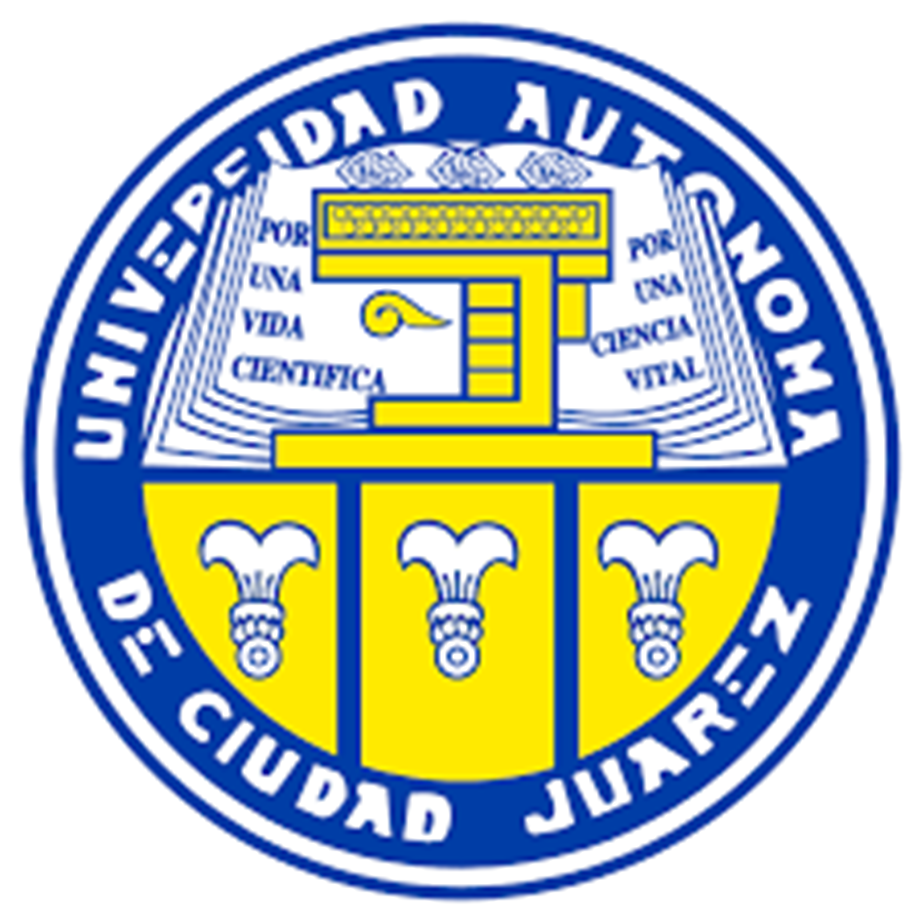


# Nombre: Sergio Trejo
# Matricula: 261539
# Materia: Redes neuronales profundas_A_Presencial_260206

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.applications import DenseNet121, ResNet50, MobileNetV2
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.applications.resnet import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import os
print(os.getcwd())

2026-02-23 22:19:00.210732: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 22:19:00.357303: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771910340.408998    2860 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771910340.427676    2860 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-23 22:19:00.585411: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

/home/sergioai/ml_projects/maestria/2do_semestre/redes_neuronales/semana_04


In [2]:
# Carpeta que contiene:
# lung_aca  -> Adenocarcinoma
# lung_n    -> Tejido sano
# lung_scc  -> Carcinoma escamoso

directory = "/home/sergioai/ml_projects/maestria/2do_semestre/redes_neuronales/semana_04/lung_image_sets"

#generador con el 15% de validacion 

# Creamos un generador de imagenes con aumento de datos (data augmentation)
# y ademas aqui mismo hacemos la separacion de 85% entrenamiento y 15% validacion.
generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=5, # rota ligeramente la imagen
    width_shift_range=0.05, # mueve la imagen horizontalmente
    height_shift_range=0.05,
    shear_range=0.05,  # aplica distorsion
    zoom_range=0.05,  # aplica zoom aleatorio
    horizontal_flip=True, #espejo horizontal
    vertical_flip=True, #espejo vertical
    validation_split=0.15,  # 15% de imagenes para validacion
    fill_mode='nearest'  # rellena los pixeles al mover/rotar
)
# Generador que cargara las imagenes para entrenamiento (85%)
training_generator = generator.flow_from_directory(
    directory,
    target_size=(224, 224),  # todas las imagenes se redimensionan a este tamano
    class_mode='categorical',  # como tenemos 3 clases, usamos one-hot encoding
    batch_size=32, # numero de imagenes por lote
    shuffle=True, # mezcla las imagenes cada epoca para que no aprenda el modelo que los datos estan en el mismo orden
    subset='training',  # toma el 85% para entrenamiento
    seed=30 # semilla para que la separacion sea siempre igual durante la aletoriedad (shuffle)
)
# Generador para validacion (15%)
val_generator = generator.flow_from_directory(
    directory,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False, # no mezclamos para mantener el mismo orden
    subset='validation', # toma el 15% reservado para ir verificando durante cada epoca
    seed=30
)

Found 12769 images belonging to 3 classes.
Found 2252 images belonging to 3 classes.


In [3]:
print(training_generator.class_indices)

{'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}


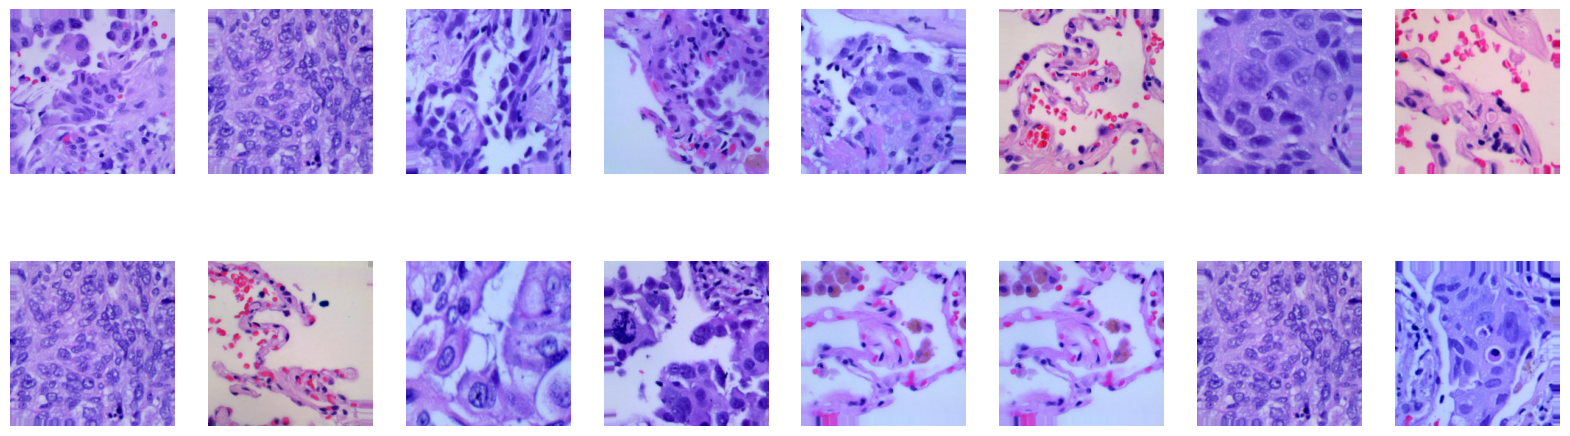

One-hot encoding:
 
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [4]:
x,y=next(training_generator)

from random import seed, randint

plt.figure(1, figsize=(20,6))
plt.tight_layout()
for i in range(8):
    j = randint(0, x.shape[0]-1)
    plt.subplot(2, 8, i+1)

    plt.imshow(x[j,:,:,:].astype(np.uint8), cmap='gray')
    plt.axis("off")
    j = randint(0, x.shape[0]-1)
    plt.subplot(2, 8, i+9)

    plt.imshow(x[j,:,:,:].astype(np.uint8), cmap='gray')
    plt.axis("off")
plt.show()
print('One-hot encoding:\n ')
print(y)

## Modelo 1 - DenseNet121

In [5]:
# Cargamos el modelo DenseNet121 preentrenado en ImageNet
# include_top=False elimina la parte final original (que clasificaba 1000 clases)
# pooling="max" reduce la salida a un vector usando Global Max Pooling
base_model = DenseNet121(
    weights='imagenet',
    input_shape=(224, 224, 3),
    include_top=False,
    pooling="max"
)

# Congelamos todas las capas convolucionales del modelo base
# Esto significa que no se entrenan, solo se usan para extraer caracteristicas
base_model.trainable = False

#configuramos nuestro modelo:
xi = tf.keras.layers.Input(shape=(224, 224, 3), dtype=tf.uint8) # Definimos la entrada del modelo: imagen de 224x224 con 3 canales (RGB)
x = preprocess_input(xi) # Aplicamos la normalizacion especial que DenseNet necesita
x = base_model(x) # Pasamos la imagen por DenseNet121 (ya congelada)
x = keras.layers.Flatten()(x) # Convertimos la salida en un vector plano para poder conectarla con capas densas
x = keras.layers.Dropout(0.2)(x) # Dropout apaga aleatoriamente neuronas para evitar sobreajuste
x = keras.layers.Dense(256, activation='relu')(x) # Primera capa densa (totalmente conectada)
x = keras.layers.BatchNormalization()(x) # BatchNormalization ayuda a entrenar mas estable y rapido 
x = keras.layers.Dense(64, activation='relu')(x) # Segunda capa densa mas pequena
x = keras.layers.BatchNormalization()(x) # Otro BatchNormalization para estabilidad
# Capa final: 3 neuronas porque tenemos 3 clases
# softmax convierte las salidas en probabilidades
xoutputs = keras.layers.Dense(3, activation='softmax')(x) 
# Construimos el modelo completo desde la entrada hasta la salida
model_densenet = Model(inputs=[xi], outputs=[xoutputs])
print(model_densenet.summary())

# Compilamos el modelo con Adam y perdida para clasificacion multiclase
model_densenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Compilamos el modelo con Adam y perdida para clasificacion multiclase
history_densenet = model_densenet.fit(
    training_generator,
    epochs=8,
    validation_data=val_generator
)

# Matriz de Confusion DenseNet
val_generator.reset()
preds = model_densenet.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_generator.class_indices.keys()
)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusion - DenseNet121")
plt.show()

W0000 00:00:1771910343.522393    2860 gpu_device.cc:2433] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1771910343.523775    2860 gpu_device.cc:2433] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1771910343.669591    2860 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13245 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0
2026-02-23 22:19:04.044280: W tensorflow/compiler/mlir/tools/kernel_gen/tf_gpu_runtime_wrappers.cc:40] 'cuModuleLoadData(&module, data)' failed with 'CUDA_ERROR_INVALID_PTX'

2026-02-23 22:19:04.044320: W tensorflow/compiler/mlir/tools/kernel_gen/tf_gpu_runtime_wrappers.cc:40] 'cuModul

InternalError: {{function_node __wrapped__Cast_device_/job:localhost/replica:0/task:0/device:GPU:0}} 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE' [Op:Cast] name: 

**Conclusiones**

El modelo DenseNet121 funciono como extractor de caracteristicas y solo se entrenaron las capas finales que agregamos, lo que confirma porque el resumen del modelo muestra que la mayoria de los parametros estan congelados. Durante el entrenamiento, la precision fue aumentando en cada epoca y la exactitud de validacion llego a valores entre 96% y 97%, cumpliendo el objetivo de la tarea. Ademas, la matriz de confusion muestra que el modelo clasifica muy bien las tres clases: el tejido normal casi no presenta errores, el adenocarcinoma y el carcinoma escamoso tambien se reconocen con alta precision y solo tienen confusiones minimas entre si. En general, DenseNet121 logro un desempeno muy alto y estable gracias a la transferencia de aprendizaje.

## Modelo 2 – ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input

base_model = ResNet50(
    weights='imagenet',
    input_shape=(224, 224, 3),
    include_top=False,
    pooling="max"
)

base_model.trainable = False

xi = tf.keras.layers.Input(shape=(224, 224, 3), dtype=tf.uint8)
x = preprocess_input(xi)
x = base_model(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
xoutputs = keras.layers.Dense(3, activation='softmax')(x)

model_resnet = Model(inputs=[xi], outputs=[xoutputs])
print(model_resnet.summary())

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet = model_resnet.fit(
    training_generator,
    epochs=8,
    validation_data=val_generator
)

# Matriz de Confusion – ResNet50
val_generator.reset()
preds = model_resnet.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_generator.class_indices.keys()
)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusion - ResNet50")
plt.show()

**Conclusiones**

El modelo ResNet50 se uso como extractor de caracteristicas y solo se entrenaron las capas densas finales que agregamos, lo cual se ve en el resumen del modelo porque la mayoria de los parametros estan congelados y solo una pequena parte es entrenable. Durante el entrenamiento, la precision aumento de manera constante y la exactitud de validacion se mantuvo en valores muy altos, entre 95% y 97%, mostrando que el modelo aprendio bien las diferencias entre los tres tipos de tejido pulmonar. En la matriz de confusion se observa que las tres clases son clasificadas con muy buena precision: el tejido normal tiene 750 aciertos sin errores, el adenocarcinoma tiene algunos pocos errores hacia carcinoma escamoso, y el carcinoma escamoso tambien presenta pocos errores hacia adenocarcinoma. En general, ResNet50 logra un desempeno alto y estable, muy similar a DenseNet, y cumple con el requisito de obtener mas del 96% de exactitud en la validacion.

## Modelo 3 – MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(
    weights='imagenet',
    input_shape=(224, 224, 3),
    include_top=False,
    pooling="max"
)

base_model.trainable = False

xi = tf.keras.layers.Input(shape=(224, 224, 3), dtype=tf.uint8)
x = preprocess_input(xi)
x = base_model(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
xoutputs = keras.layers.Dense(3, activation='softmax')(x)

model_mobilenet = Model(inputs=[xi], outputs=[xoutputs])
print(model_mobilenet.summary())

model_mobilenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = model_mobilenet.fit(
    training_generator,
    epochs=8,
    validation_data=val_generator
)

# Matriz de Confusion – MobileNetV2
val_generator.reset()
preds = model_mobilenet.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_generator.class_indices.keys()
)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusion - MobileNetV2")
plt.show()

**Conclusion**

El modelo MobileNetV2 tambien se uso como un extractor de caracteristicas y solo entrenamos las capas finales que agregamos. Esto hace que el modelo sea mucho mas ligero y rapido que DenseNet y ResNet, pero aun asi logra muy buen rendimiento. En el resumen del modelo se ve claramente que casi todos los parametros estan congelados y que la parte entrenable es pequena. Durante las epocas, la precision fue subiendo de manera constante y la exactitud de validacion se mantuvo entre 96% y 98%, lo cual cumple con lo que pide la tarea. En la matriz de confusion se ve que el modelo distingue muy bien las tres clases de pulmon: el tejido normal se clasifica perfecto, el adenocarcinoma tiene pocos errores hacia carcinoma escamoso y viceversa. En general, MobileNetV2 funciona muy bien, es rapido y logra excelente precision usando transferencia de aprendizaje.